# 03 Baseline Logistic Regression

This notebook builds a leakage-safe baseline logistic regression model to predict `Outcome` from the raw cardiac patient dataset. The workflow:

1. Loads `data/CardiacPatientData.csv`.
2. Checks whether `ID` values repeat.
3. Uses a group-aware split when repeated IDs are present; otherwise uses a stratified split.
4. Applies deterministic clinical feature engineering separately to train and test data.
5. Fits a scikit-learn `Pipeline` with imputation, numeric scaling, categorical encoding, and logistic regression.
6. Evaluates the model on a held-out test set.
7. Saves metrics to `reports/baseline_logistic_regression_metrics.csv` and plots to `reports/figures/`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Resolve paths robustly whether the notebook is run from the repository root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'CardiacPatientData.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import add_clinical_features

DATA_PATH = PROJECT_ROOT / 'data' / 'CardiacPatientData.csv'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
METRICS_PATH = REPORTS_DIR / 'baseline_logistic_regression_metrics.csv'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
sns.set_theme(style='whitegrid')

## Load raw data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
display(df.head())
display(df.dtypes.to_frame('dtype'))

class_balance = df['Outcome'].value_counts(dropna=False).rename_axis('Outcome').to_frame('count')
class_balance['proportion'] = class_balance['count'] / len(df)
display(class_balance)

Dataset shape: 5,906 rows x 20 columns


,ID,SBP,DBP,HR,RR,BT,SpO2,Age,Gender,GCS,Na,K,Cl,Urea,Ceratinine,Alcoholic,Smoke,FHCD,TriageScore,Outcome
0,1,163,95,90,18,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
1,1,134,85,85,15,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
2,1,121,77,80,19,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
3,1,103,78,70,16,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
4,1,96,70,59,13,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1


,dtype
ID,int64
SBP,int64
DBP,int64
HR,int64
RR,int64
BT,int64
SpO2,int64
Age,int64
Gender,int64
GCS,int64


,count,proportion
Outcome,,
1,5053,0.855571
0,853,0.144429


## Check repeated patient IDs and choose leakage-safe split

Repeated `ID` values indicate multiple rows per patient. In that case, all rows for a patient must remain in the same split to prevent the model from seeing near-duplicate or longitudinal measurements for the same patient during training and testing. If IDs do not repeat, a standard stratified train/test split is used.

In [3]:
id_counts = df['ID'].value_counts()
ids_repeat = bool((id_counts > 1).any())
print(f'Unique IDs: {df["ID"].nunique():,}')
print(f'Rows: {len(df):,}')
print(f'Any repeated ID values? {ids_repeat}')

if ids_repeat:
    repeated_id_summary = id_counts[id_counts > 1].describe().to_frame('rows_per_repeated_id')
    display(repeated_id_summary)
    print('Using group-aware splitting by ID.')
else:
    print('Using stratified train/test splitting because IDs do not repeat.')

Unique IDs: 112
Rows: 5,906
Any repeated ID values? True


,rows_per_repeated_id
count,108.000000
mean,54.648148
std,34.072851
min,3.000000
25%,37.000000
50%,51.000000
75%,70.000000
max,266.000000


Using group-aware splitting by ID.


In [4]:
X_raw = df.drop(columns=['Outcome'])
y = df['Outcome'].astype(int)

if ids_repeat:
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(X_raw, y, groups=df['ID']))
    split_strategy = 'StratifiedGroupKFold by patient ID'
else:
    train_idx, test_idx = train_test_split(
        np.arange(len(df)),
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    split_strategy = 'Stratified train/test split'

train_raw = df.iloc[train_idx].copy()
test_raw = df.iloc[test_idx].copy()

train_ids = set(train_raw['ID'])
test_ids = set(test_raw['ID'])
overlapping_ids = train_ids.intersection(test_ids)

print(f'Split strategy: {split_strategy}')
print(f'Train rows: {len(train_raw):,}; test rows: {len(test_raw):,}')
print(f'Train unique IDs: {train_raw["ID"].nunique():,}; test unique IDs: {test_raw["ID"].nunique():,}')
print(f'Overlapping IDs across train/test: {len(overlapping_ids):,}')

split_balance = pd.concat(
    {
        'train': train_raw['Outcome'].value_counts(normalize=True).sort_index(),
        'test': test_raw['Outcome'].value_counts(normalize=True).sort_index(),
    },
    axis=1,
).fillna(0)
display(split_balance)

Split strategy: StratifiedGroupKFold by patient ID
Train rows: 4,826; test rows: 1,080
Train unique IDs: 90; test unique IDs: 22
Overlapping IDs across train/test: 0


,train,test
Outcome,,
0,0.150228,0.118519
1,0.849772,0.881481


## Feature engineering

The added features are deterministic row-wise transformations from `src.features.add_clinical_features`, so they do not learn population statistics. They are applied after splitting and separately to train/test data to maintain a leakage-safe workflow. The patient `ID` column is excluded from model features so the classifier cannot memorize patient identifiers.

In [5]:
train_features = add_clinical_features(train_raw.drop(columns=['Outcome']))
test_features = add_clinical_features(test_raw.drop(columns=['Outcome']))

y_train = train_raw['Outcome'].astype(int)
y_test = test_raw['Outcome'].astype(int)

# Avoid ID leakage/memorization. Outcome has already been separated.
X_train = train_features.drop(columns=['ID'])
X_test = test_features.drop(columns=['ID'])

engineered_columns = [col for col in X_train.columns if col not in df.drop(columns=['ID', 'Outcome']).columns]
print('Engineered feature columns:')
for col in engineered_columns:
    print(f'- {col}')

display(X_train.head())

Engineered feature columns:
- pulse_pressure
- shock_index
- age_band
- hypoxemia_flag
- gcs_severity
- sodium_abnormal_flag
- potassium_abnormal_flag
- chloride_abnormal_flag
- urea_abnormal_flag
- creatinine_abnormal_flag


,SBP,DBP,HR,RR,BT,SpO2,Age,Gender,GCS,Na,...,pulse_pressure,shock_index,age_band,hypoxemia_flag,gcs_severity,sodium_abnormal_flag,potassium_abnormal_flag,chloride_abnormal_flag,urea_abnormal_flag,creatinine_abnormal_flag
41,138,91,80,16,98,99,52,1,15,142.0,...,47,0.579710,40-64,0,mild,0,0,1,0,0
42,146,93,83,15,98,99,52,1,15,142.0,...,53,0.568493,40-64,0,mild,0,0,1,0,0
43,140,82,69,18,98,98,52,1,15,142.0,...,58,0.492857,40-64,0,mild,0,0,1,0,0
44,129,85,90,13,98,99,52,1,15,142.0,...,44,0.697674,40-64,0,mild,0,0,1,0,0
45,145,81,86,16,98,99,52,1,15,142.0,...,64,0.593103,40-64,0,mild,0,0,1,0,0


## Build preprocessing and logistic regression pipeline

The pipeline imputes missing values, scales numeric features, one-hot encodes categorical/ordinal/binary flag features, and fits regularized logistic regression.

In [6]:
categorical_features = [
    'Gender',
    'Alcoholic',
    'Smoke',
    'FHCD',
    'TriageScore',
    'age_band',
    'gcs_severity',
    'hypoxemia_flag',
    'sodium_abnormal_flag',
    'potassium_abnormal_flag',
    'chloride_abnormal_flag',
    'urea_abnormal_flag',
    'creatinine_abnormal_flag',
]
categorical_features = [col for col in categorical_features if col in X_train.columns]
numeric_features = [col for col in X_train.columns if col not in categorical_features]

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

# Convert categorical columns to object dtype and normalize pandas NA values to np.nan
# so SimpleImputer/OneHotEncoder handle nullable integer flags consistently.
X_train_model = X_train.copy()
X_test_model = X_test.copy()
for col in categorical_features:
    X_train_model[col] = X_train_model[col].astype('object').where(X_train_model[col].notna(), np.nan)
    X_test_model[col] = X_test_model[col].astype('object').where(X_test_model[col].notna(), np.nan)

numeric_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numeric_features),
        ('categorical', categorical_pipeline, categorical_features),
    ],
    remainder='drop',
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]
)

model

Numeric features (15): ['SBP', 'DBP', 'HR', 'RR', 'BT', 'SpO2', 'Age', 'GCS', 'Na', 'K', 'Cl', 'Urea', 'Ceratinine', 'pulse_pressure', 'shock_index']
Categorical features (13): ['Gender', 'Alcoholic', 'Smoke', 'FHCD', 'TriageScore', 'age_band', 'gcs_severity', 'hypoxemia_flag', 'sodium_abnormal_flag', 'potassium_abnormal_flag', 'chloride_abnormal_flag', 'urea_abnormal_flag', 'creatinine_abnormal_flag']


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Fit model

In [7]:
model.fit(X_train_model, y_train)
print('Model fit complete.')

Model fit complete.


## Evaluate on held-out test set

In [8]:
y_proba = model.predict_proba(X_test_model)[:, 1]
y_pred = model.predict(X_test_model)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

metrics = {
    'split_strategy': split_strategy,
    'train_rows': len(train_raw),
    'test_rows': len(test_raw),
    'train_unique_ids': train_raw['ID'].nunique(),
    'test_unique_ids': test_raw['ID'].nunique(),
    'overlapping_train_test_ids': len(overlapping_ids),
    'positive_class': 1,
    'auroc': roc_auc_score(y_test, y_proba),
    'auprc': average_precision_score(y_test, y_proba),
    'accuracy': accuracy_score(y_test, y_pred),
    'sensitivity_recall': recall_score(y_test, y_pred, zero_division=0),
    'specificity': tn / (tn + fp) if (tn + fp) else np.nan,
    'precision_ppv': precision_score(y_test, y_pred, zero_division=0),
    'npv': tn / (tn + fn) if (tn + fn) else np.nan,
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'true_negative': tn,
    'false_positive': fp,
    'false_negative': fn,
    'true_positive': tp,
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(METRICS_PATH, index=False)
print(f'Saved metrics to: {METRICS_PATH.relative_to(PROJECT_ROOT)}')
display(metrics_df.T.rename(columns={0: 'value'}))

confusion_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=[0, 1]),
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1'],
)
display(confusion_df)

Saved metrics to: reports\baseline_logistic_regression_metrics.csv


,value
split_strategy,StratifiedGroupKFold by patient ID
train_rows,4826
test_rows,1080
train_unique_ids,90
test_unique_ids,22
overlapping_train_test_ids,0
positive_class,1
auroc,0.693433
auprc,0.93871
accuracy,0.735185


,Predicted 0,Predicted 1
Actual 0,72,56
Actual 1,230,722


## Save evaluation plots

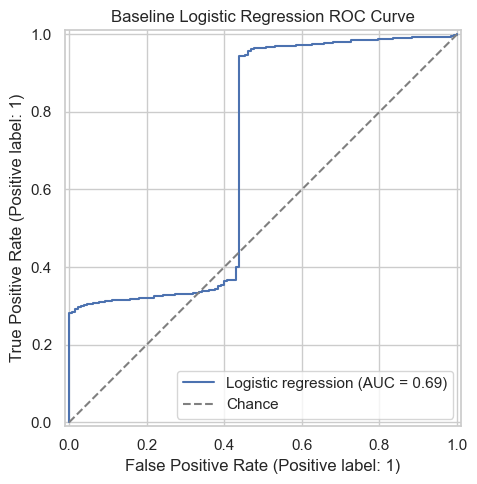

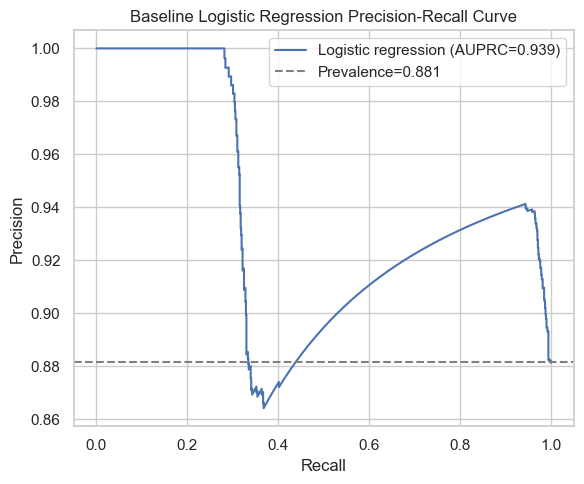

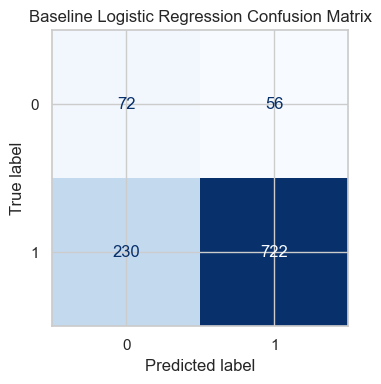

Saved plots:
- reports\figures\baseline_logistic_regression_roc_curve.png
- reports\figures\baseline_logistic_regression_precision_recall_curve.png
- reports\figures\baseline_logistic_regression_confusion_matrix.png


In [9]:
roc_path = FIGURES_DIR / 'baseline_logistic_regression_roc_curve.png'
pr_path = FIGURES_DIR / 'baseline_logistic_regression_precision_recall_curve.png'
cm_path = FIGURES_DIR / 'baseline_logistic_regression_confusion_matrix.png'

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='Logistic regression')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('Baseline Logistic Regression ROC Curve')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, label=f'Logistic regression (AUPRC={metrics["auprc"]:.3f})')
ax.axhline(y_test.mean(), linestyle='--', color='gray', label=f'Prevalence={y_test.mean():.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Baseline Logistic Regression Precision-Recall Curve')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(pr_path, dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[0, 1], cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Baseline Logistic Regression Confusion Matrix')
fig.tight_layout()
fig.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

print('Saved plots:')
for path in [roc_path, pr_path, cm_path]:
    print(f'- {path.relative_to(PROJECT_ROOT)}')

## Conclusion

This notebook establishes a leakage-safe baseline logistic regression model for predicting cardiac arrest outcomes. The workflow uses an appropriate train/test split, excludes patient ID from the model, applies clinical feature engineering after splitting, and evaluates performance on a held-out test set using clinically relevant metrics.

The model provides an interpretable starting point for prediction, but it should be treated as a baseline rather than the final model. Its main value is setting a reproducible comparison point for future models. Next steps should include reviewing feature importance, tuning thresholds for sensitivity versus specificity, testing alternative models, and comparing performance using AUROC, AUPRC, recall, precision, F1 score, and calibration.